In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2025-12-10 08:39:10.146577


# Project Xenium Signature to Sequencing Data

**Pinned Environment:** [`envs/sc-scvi.yaml`](../.../envs/sc-scvi.yaml)  

In [1]:
from pathlib import Path
import os
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import sparse
import warnings
import session_info
import sys

In [2]:
plt.rcParams["figure.figsize"] = (3, 3)
plt.rcParams["figure.dpi"] = 150

### Setup

In [3]:
base_dir = "/home/workspace/private/projects/kim/drg"
panel_dir = os.path.join(base_dir, "panel/gene-lists/drafts")
adata_path = os.path.join(
    base_dir, "data/scrna-seq/h5ad/04_clustered/GSE139088-scvi-leiden.h5ad"
)

In [5]:
adata = sc.read_h5ad(adata_path)

In [12]:
genes = [
    "Chrna3",
    "Cartpt",
    "Hpse",
    "Htr3b",
    "Mrap2",
    "Htr3a",
    "Mgat5b",
    "Piezo2",
    "Ctcflos",
    "Adra2a",
    "Chrnb4",
    "Chrna3",
    "Trpv1",
    "Asic3",
    "Kcnq3",
    "original_annotation",
]

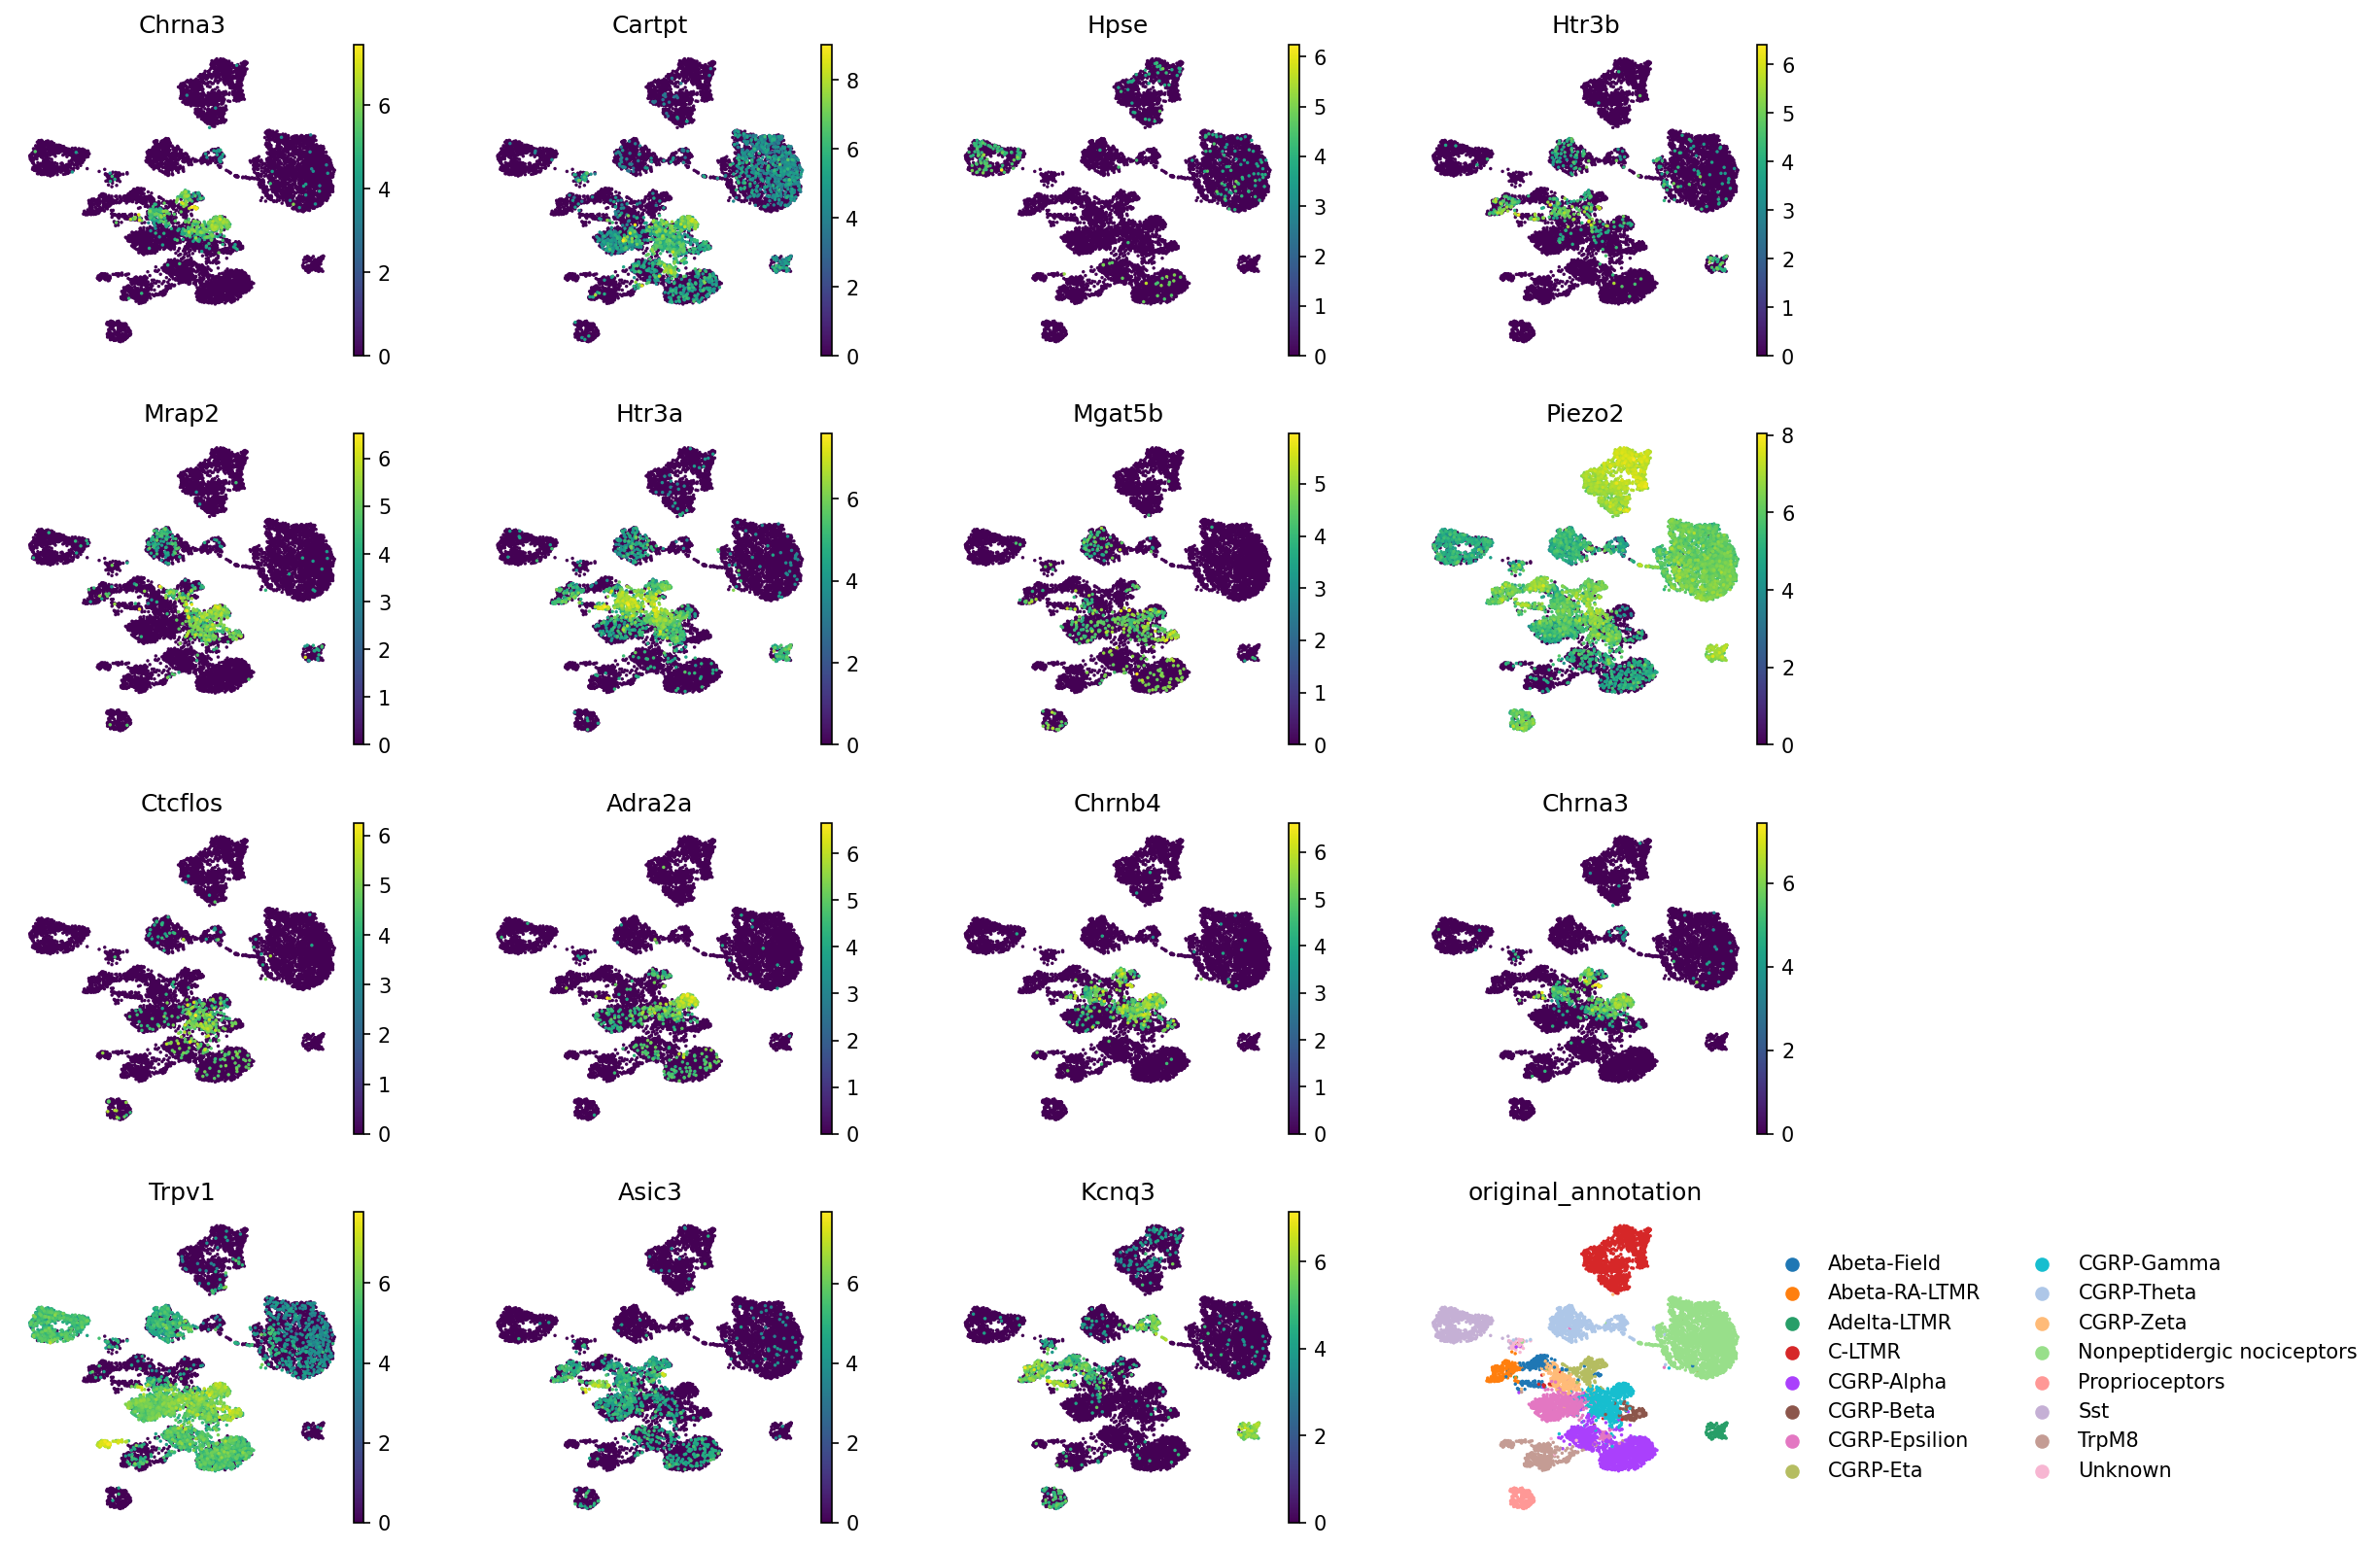

In [13]:
sc.pl.umap(adata, color=genes, frameon=False)

In [14]:
import scanpy as sc

# --- 1. Define your gene list ---
dual_signature_genes = [
    "Chrna3",
    "Cartpt",
    "Hpse",
    "Htr3b",
    "Mrap2",
    "Htr3a",
    "Mgat5b",
    "Chrnb4",
    "Ntrk2",
    "Pou4f2",
]

# --- 2. Filter to genes that are actually present in the dataset ---
genes_present = [g for g in dual_signature_genes if g in adata.var_names]

print(
    f"Using {len(genes_present)} / {len(dual_signature_genes)} genes present in adata:"
)
print(genes_present)

# --- 3. Score the gene set ---
sc.tl.score_genes(
    adata, gene_list=genes_present, score_name="dual_positive_signature_score"
)

print("\nAdded adata.obs['dual_positive_signature_score']")

Using 10 / 10 genes present in adata:
['Chrna3', 'Cartpt', 'Hpse', 'Htr3b', 'Mrap2', 'Htr3a', 'Mgat5b', 'Chrnb4', 'Ntrk2', 'Pou4f2']

Added adata.obs['dual_positive_signature_score']


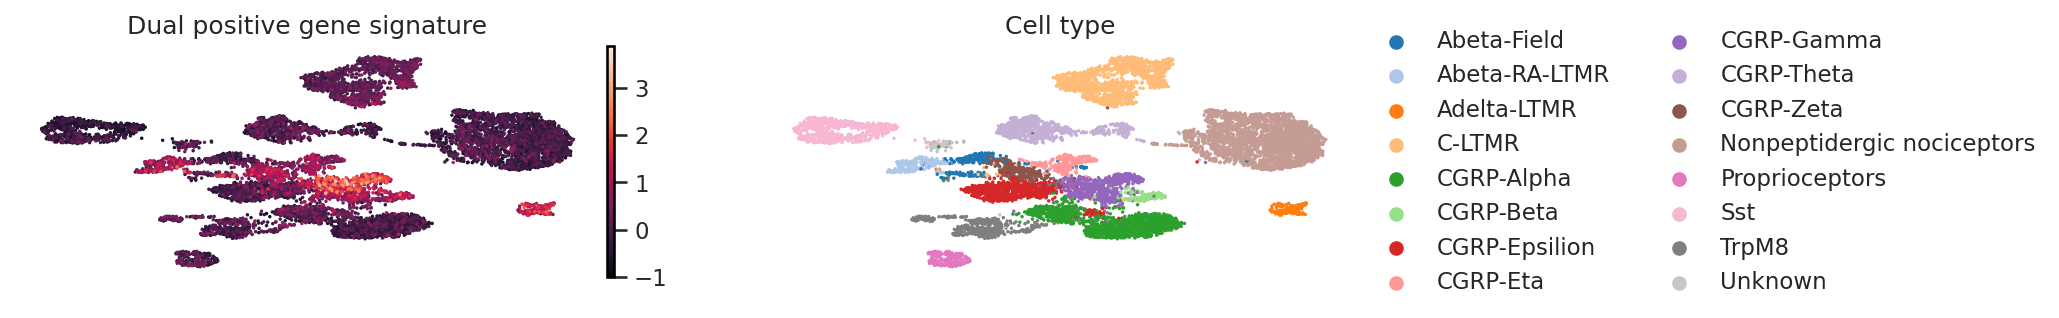

In [81]:
sc.pl.umap(
    adata,
    color=["dual_positive_signature_score", "original_annotation"],
    frameon=False,
    title=["Dual positive gene signature", "Cell type"],
)

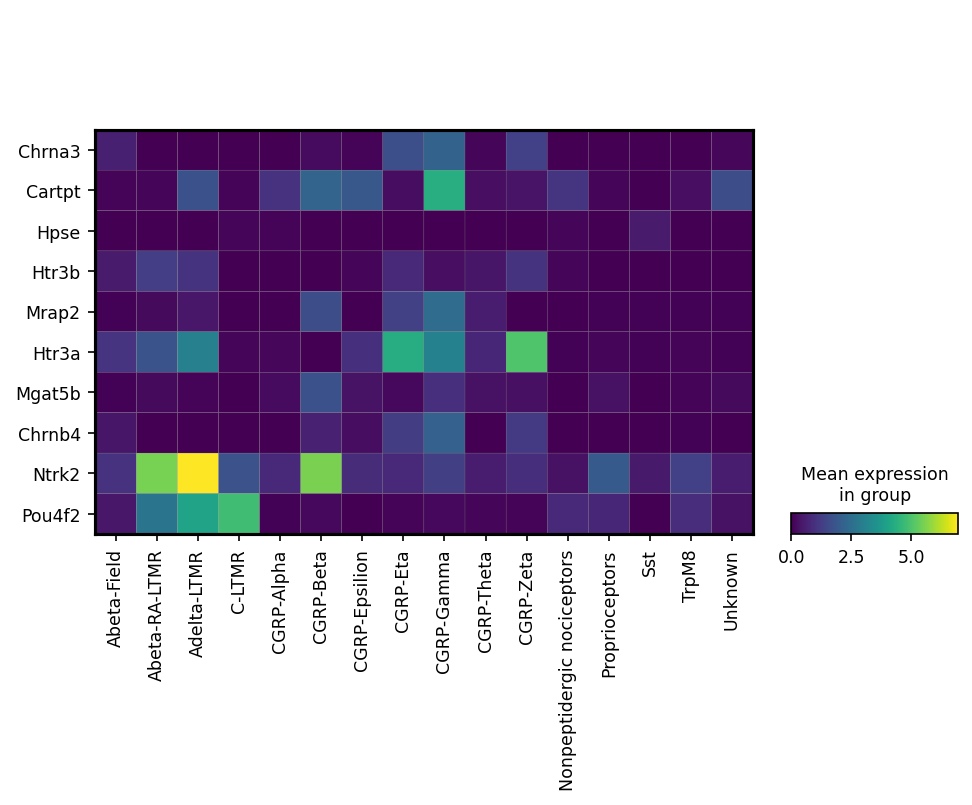

In [48]:
sc.pl.matrixplot(
    adata,
    var_names=dual_signature_genes,
    groupby="original_annotation",
    swap_axes=True,
    standard_scale=True,
)

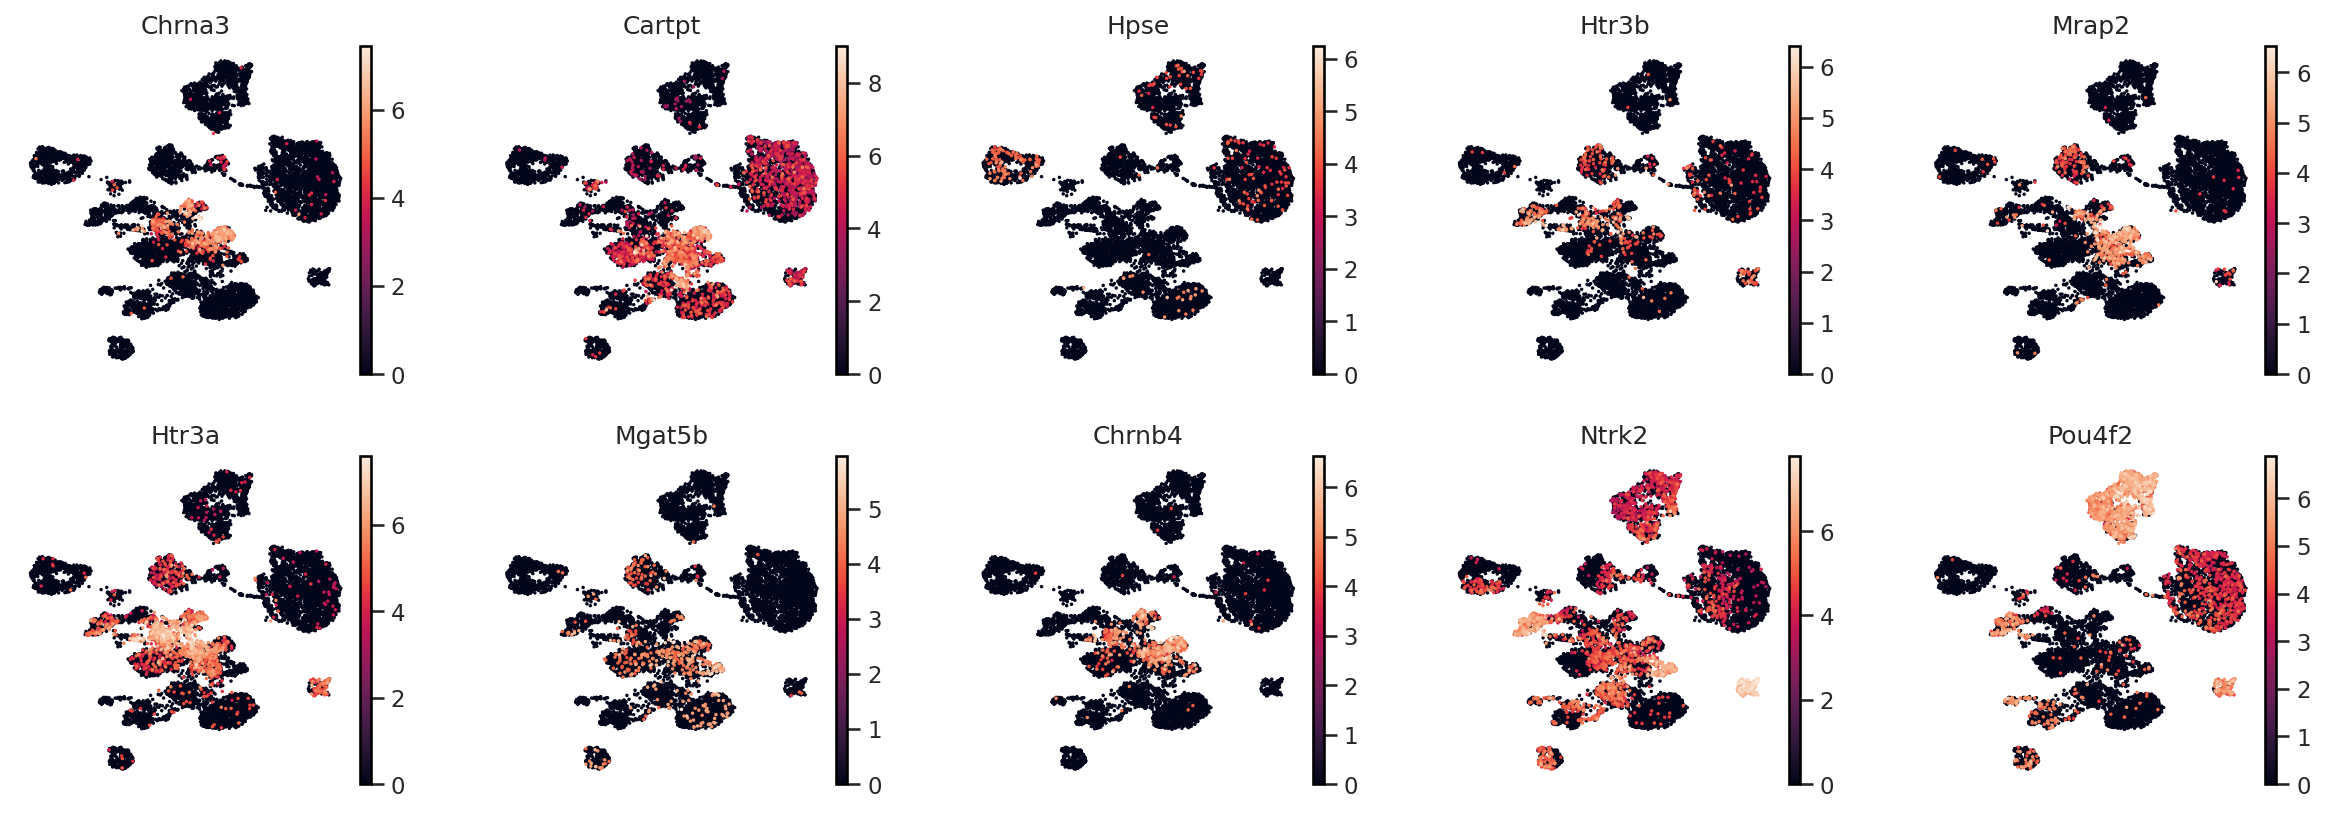

In [101]:
sc.pl.umap(
    adata,
    color=[
        "Chrna3",
        "Cartpt",
        "Hpse",
        "Htr3b",
        "Mrap2",
        "Htr3a",
        "Mgat5b",
        "Chrnb4",
        "Ntrk2",
        "Pou4f2",
    ],
    ncols=5,
    frameon=False,
)

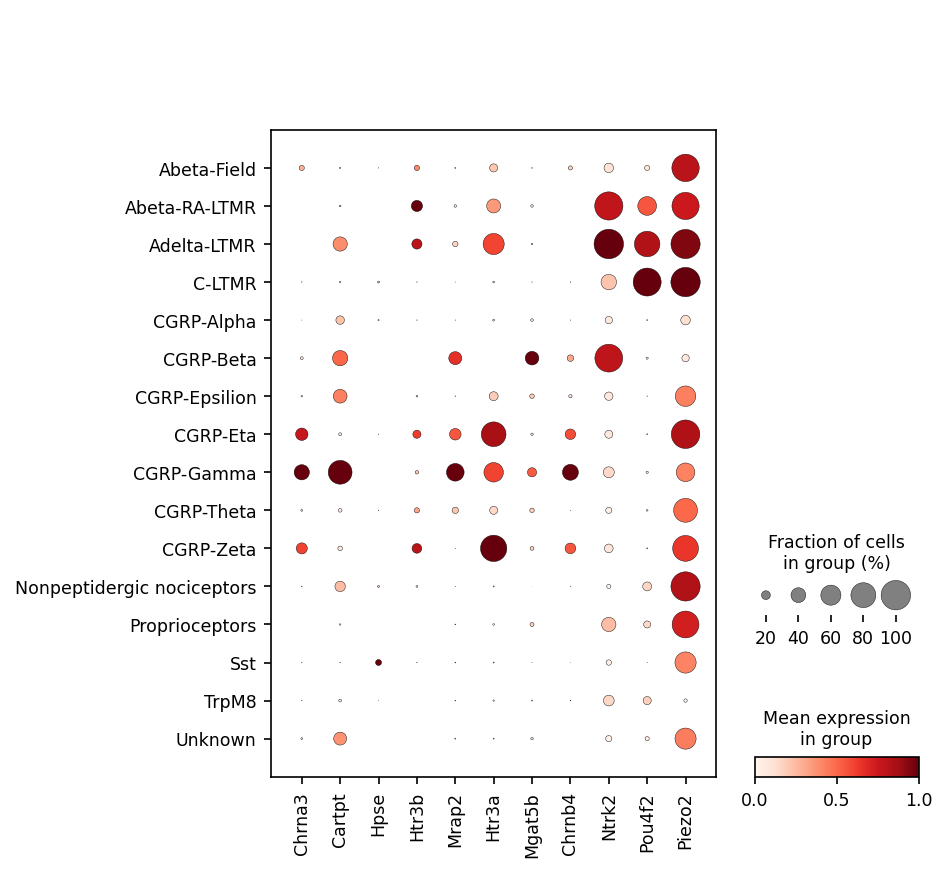

In [49]:
sc.pl.dotplot(
    adata,
    var_names=[
        "Chrna3",
        "Cartpt",
        "Hpse",
        "Htr3b",
        "Mrap2",
        "Htr3a",
        "Mgat5b",
        "Chrnb4",
        "Ntrk2",
        "Pou4f2",
        "Piezo2",
    ],
    groupby="original_annotation",
    standard_scale="var",
)

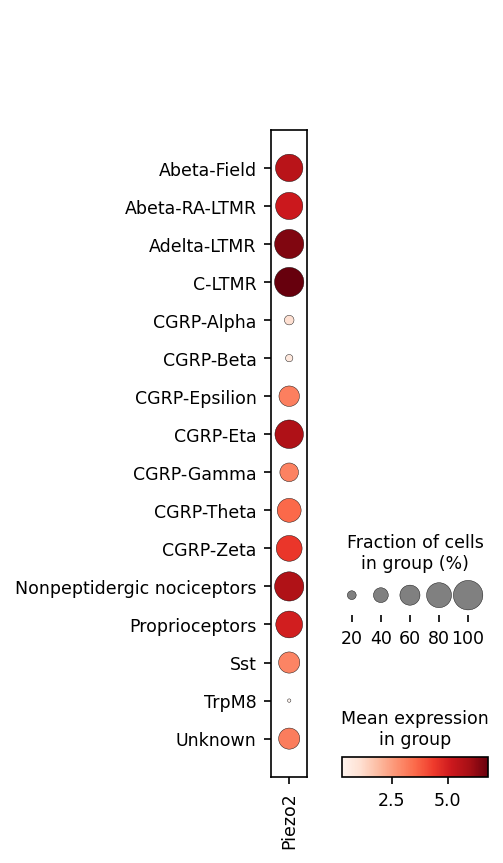

In [26]:
sc.pl.dotplot(adata, var_names="Piezo2", groupby="original_annotation")

In [79]:
def assign_cell_type_colors(adata, key="cell_type"):
    """Assigns a HUSL color palette to a categorical obs field."""
    adata.obs[key] = adata.obs[key].astype("category")
    num_categories = len(adata.obs[key].cat.categories)

    palette = sns.color_palette("tab20", n_colors=num_categories)
    adata.uns[f"{key}_colors"] = [mcolors.to_hex(c) for c in palette]

    print(f"Assigned {num_categories} HUSL colors for `{key}`.")


assign_cell_type_colors(adata, key="original_annotation")

Assigned 16 HUSL colors for `original_annotation`.


/tmp/ipykernel_2939/494481934.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


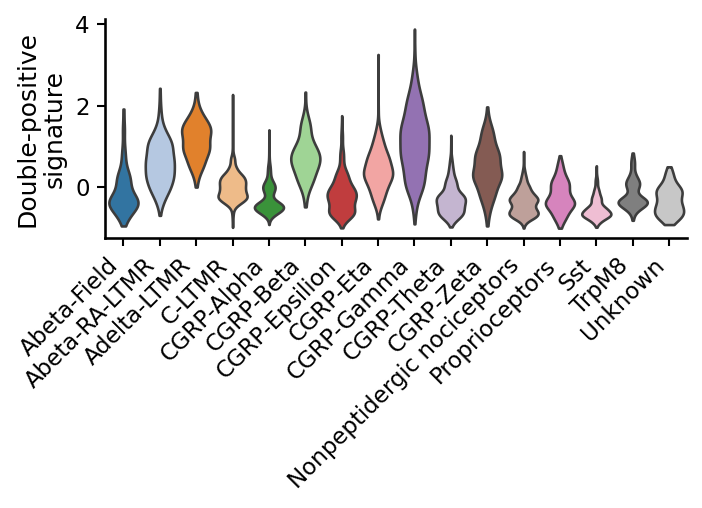

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------
# Minimal clean theme
# ---------------------------
sns.set_theme(style="white")

plt.rcParams["figure.figsize"] = (5, 2)  # <-- ONLY CHANGE (shorter height)
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.spines.left"] = True
plt.rcParams["axes.spines.bottom"] = True
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.labelsize"] = 12

# ---------------------------
# Generate violin without showing
# ---------------------------
ax = sc.pl.violin(
    adata,
    keys="dual_positive_signature_score",
    groupby="original_annotation",
    stripplot=False,
    jitter=False,
    inner=None,
    show=False,
)

# ---------------------------
# Force visible ticks + labels
# ---------------------------
ax.tick_params(
    axis="x",
    which="both",
    bottom=True,
    top=False,
    length=4,
    width=1,
    color="black",
    labelcolor="black",
)

ax.tick_params(
    axis="y",
    which="both",
    left=True,
    right=False,
    length=4,
    width=1,
    color="black",
    labelcolor="black",
)

# ---------------------------
# Fix xtick labels (rotation + color)
# ---------------------------
xticklabels = [t.get_text() for t in ax.get_xticklabels()]
ax.set_xticks(range(len(xticklabels)))
ax.set_xticklabels(xticklabels, rotation=45, ha="right", color="black")

# ---------------------------
# Labels
# ---------------------------
ax.set_ylabel("Double-positive\nsignature", fontsize=12, color="black")
ax.set_xlabel("")

sns.despine()
plt.tight_layout()
plt.show()

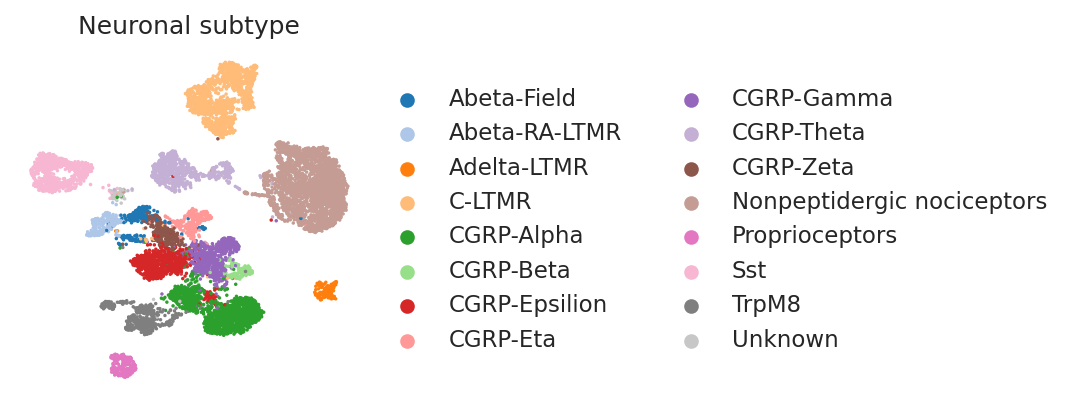

In [95]:
plt.rcParams["figure.figsize"] = (3, 3)
sc.pl.umap(
    adata,
    color=["original_annotation"],
    frameon=False,
    title=["Neuronal subtype"],
    cmap="Purples",
    vmax=3,
)  # , legend_loc = 'none')

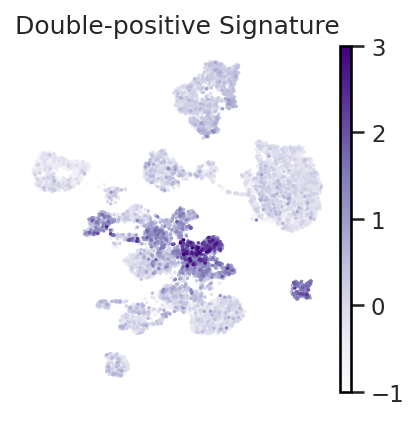

In [91]:
sc.pl.umap(
    adata,
    color=["dual_positive_signature_score"],
    frameon=False,
    title=["Double-positive Signature"],
    cmap="Purples",
    vmax=3,
)

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt


def pretty_violin(
    adata,
    key="dual_positive_signature_score",
    groupby="original_annotation",
    figsize=(6, 4),
    palette="viridis",
):
    df = adata.obs[[groupby, key]].copy()
    df = df.dropna()

    plt.figure(figsize=figsize, dpi=300)
    sns.set_theme(style="whitegrid")

    # Draw violins
    sns.violinplot(
        data=df,
        x=groupby,
        y=key,
        palette=palette,
        cut=0,
        linewidth=1.2,
        inner=None,  # remove messy internal bars
        alpha=0.8,
    )

    # Overlay jittered points
    sns.stripplot(
        data=df, x=groupby, y=key, color="black", alpha=0.35, size=2, jitter=0.25
    )

    plt.xticks(rotation=90, fontsize=10)
    plt.ylabel(key.replace("_", " "), fontsize=12)
    plt.xlabel("")
    sns.despine()
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_2939/2813270641.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


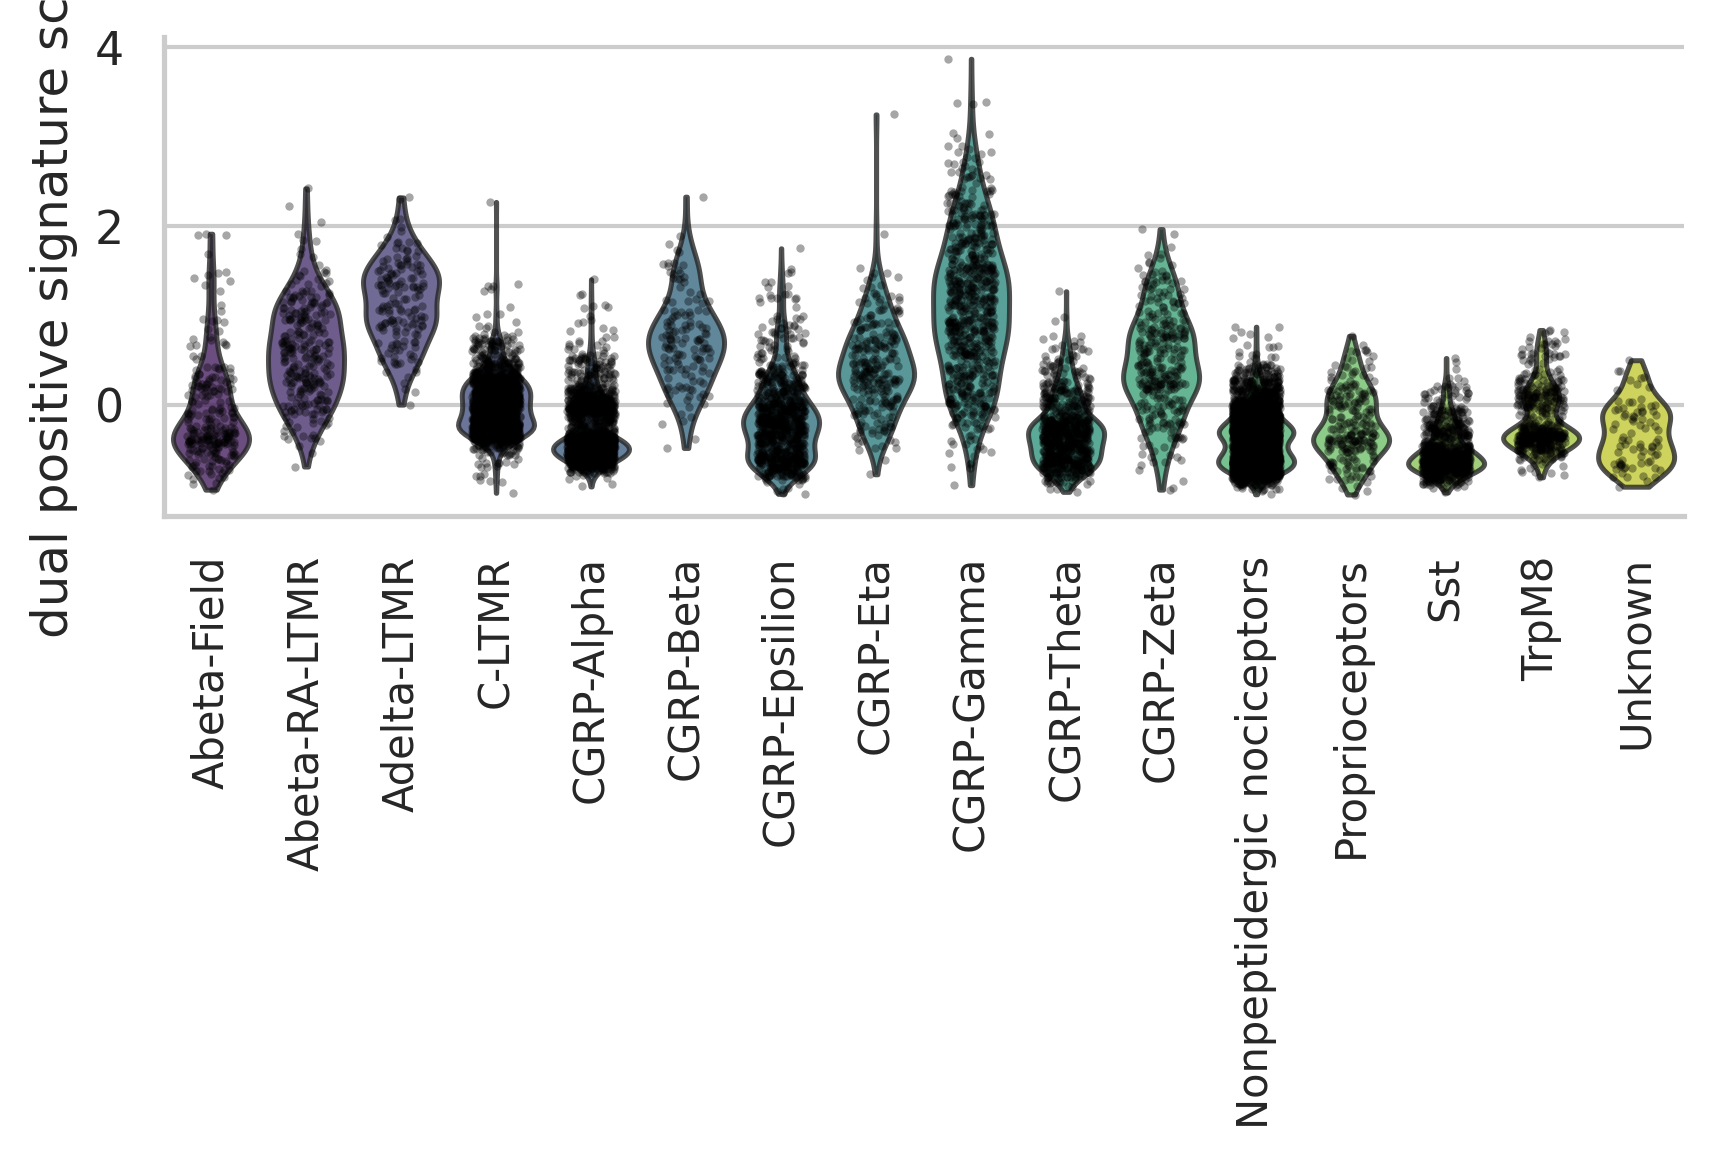

In [59]:
pretty_violin(adata, key="dual_positive_signature_score", groupby="original_annotation")

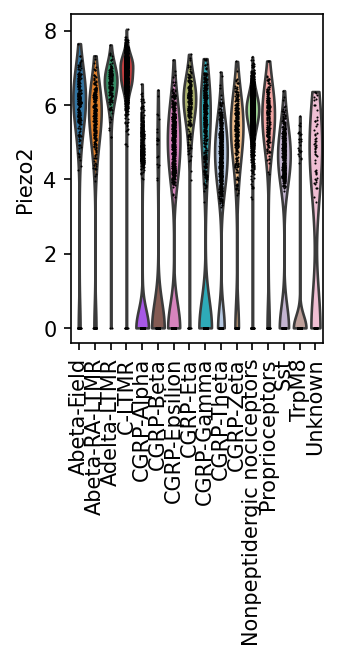

In [23]:
sc.pl.violin(adata, keys="Piezo2", groupby="original_annotation", rotation=90)